# Spatial Proteomics Segmentation

In this training notebook, we build a `SpatialData` object from multiplexed protein imaging data, generate and refine cell segmentation masks, quantify marker intensities per cell, and use the resulting table for clustering.

In [2]:
import harpy as hp
import spatialdata_plot

_ = spatialdata_plot

## 1. Create the SpatialData object

In [17]:
import tempfile
from pathlib import Path

from spatialdata import read_zarr

tmp = tempfile.TemporaryDirectory(prefix="vectrapolaris_")
output_dir = Path(tmp.name)

path = None

sdata = hp.datasets.vectra_example(
    path=path,
)
sdata.write(output_dir / "sdata.zarr", overwrite=True)

sdata = read_zarr(sdata.path)

sdata

2026-05-24 20:20:47.425 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'image'


SpatialData object, with associated Zarr store: /private/var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/vectrapolaris_vnbldvv0/sdata.zarr
└── Images
      └── 'image': DataTree[cyx] (8, 1400, 1868), (8, 700, 934), (8, 350, 467), (8, 175, 233)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images)
    ▸ 'global_micron', with elements:
        image (Images)

In [18]:
sdata["image"]

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 8, y: 1400, x: 1868)
│       Coordinates:
│         * c        (c) <U16 512B 'PDL1' 'CD8' 'FoxP3' ... 'DAPI' 'Autofluorescence'
│         * y        (y) float64 11kB 0.5 1.5 2.5 3.5 ... 1.398e+03 1.398e+03 1.4e+03
│         * x        (x) float64 15kB 0.5 1.5 2.5 3.5 ... 1.866e+03 1.866e+03 1.868e+03
│       Data variables:
│           image    (c, y, x) float32 84MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 8, y: 700, x: 934)
│       Coordinates:
│         * c        (c) <U16 512B 'PDL1' 'CD8' 'FoxP3' ... 'DAPI' 'Autofluorescence'
│         * y        (y) float64 6kB 1.0 3.0 5.0 7.0 ... 1.395e+03 1.397e+03 1.399e+03
│         * x        (x) float64 7kB 1.0 3.0 5.0 7.0 ... 1.863e+03 1.865e+03 1.867e+03
│       Data variables:
│           image    (c, y, x) float32 21MB dask.array<chunksize=(1, 700, 934), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 8, y: 350, x: 467)
│       Coordinates:
│         * c        (c) <U16 512B 'PDL1' 'CD8' 'FoxP3' ... 'DAPI' 'Autofluorescence'
│         * y        (y) float64 3kB 2.0 6.0 10.0 14.0 ... 1.39e+03 1.394e+03 1.398e+03
│         * x        (x) float64 4kB 2.0 6.0 10.0 14.0 ... 1.858e+03 1.862e+03 1.866e+03
│       Data variables:
│           image    (c, y, x) float32 5MB dask.array<chunksize=(1, 350, 467), meta=np.ndarray>
└── Group: /scale3
        Dimensions:  (c: 8, y: 175, x: 233)
        Coordinates:
          * c        (c) <U16 512B 'PDL1' 'CD8' 'FoxP3' ... 'DAPI' 'Autofluorescence'
          * y        (y) float64 1kB 4.0 12.0 20.0 28.0 ... 1.38e+03 1.388e+03 1.396e+03
          * x        (x) float64 2kB 4.009 12.03 20.04 ... 1.848e+03 1.856e+03 1.864e+03
        Data variables:
            image    (c, y, x) float32 1MB dask.array<chunksize=(1, 175, 233), meta=np.ndarray>

In [42]:
from spatialdata.transformations import get_transformation

get_transformation(sdata["image"], get_all=True)

{'global': Identity ,
 'global_micron': Scale (c, y, x)
     [1.         0.49799448 0.49799448]}

In [4]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

In [19]:
# good practice to rechunk on disk
from spatialdata.transformations import get_transformation

sdata = hp.im.add_image(
    sdata,
    arr=hp.im.get_dataarray(sdata, element_name="image").data.rechunk((8, 500, 500)),
    output_image_name="image",
    scale_factors=[2, 2, 2],
    c_coords=hp.im.get_dataarray(sdata, element_name="image").c.data,
    transformations=get_transformation(sdata["image"], get_all=True),
    overwrite=True,
)

2026-05-24 20:21:52.331 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'image'
2026-05-24 20:21:52.633 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'image' already exists. Overwriting...


In [20]:
sdata.is_backed()

True

In [21]:
channels = hp.im.get_dataarray(sdata, element_name="image").c.data
channels

array(['PDL1', 'CD8', 'FoxP3', 'CD68', 'PD1', 'CK', 'DAPI',
       'Autofluorescence'], dtype='<U16')

In [24]:
channels = hp.im.get_dataarray(sdata, element_name="image").c.data
channels

array(['PDL1', 'CD8', 'FoxP3', 'CD68', 'PD1', 'CK', 'DAPI',
       'Autofluorescence'], dtype='<U16')

## 2. Inspect the image channels

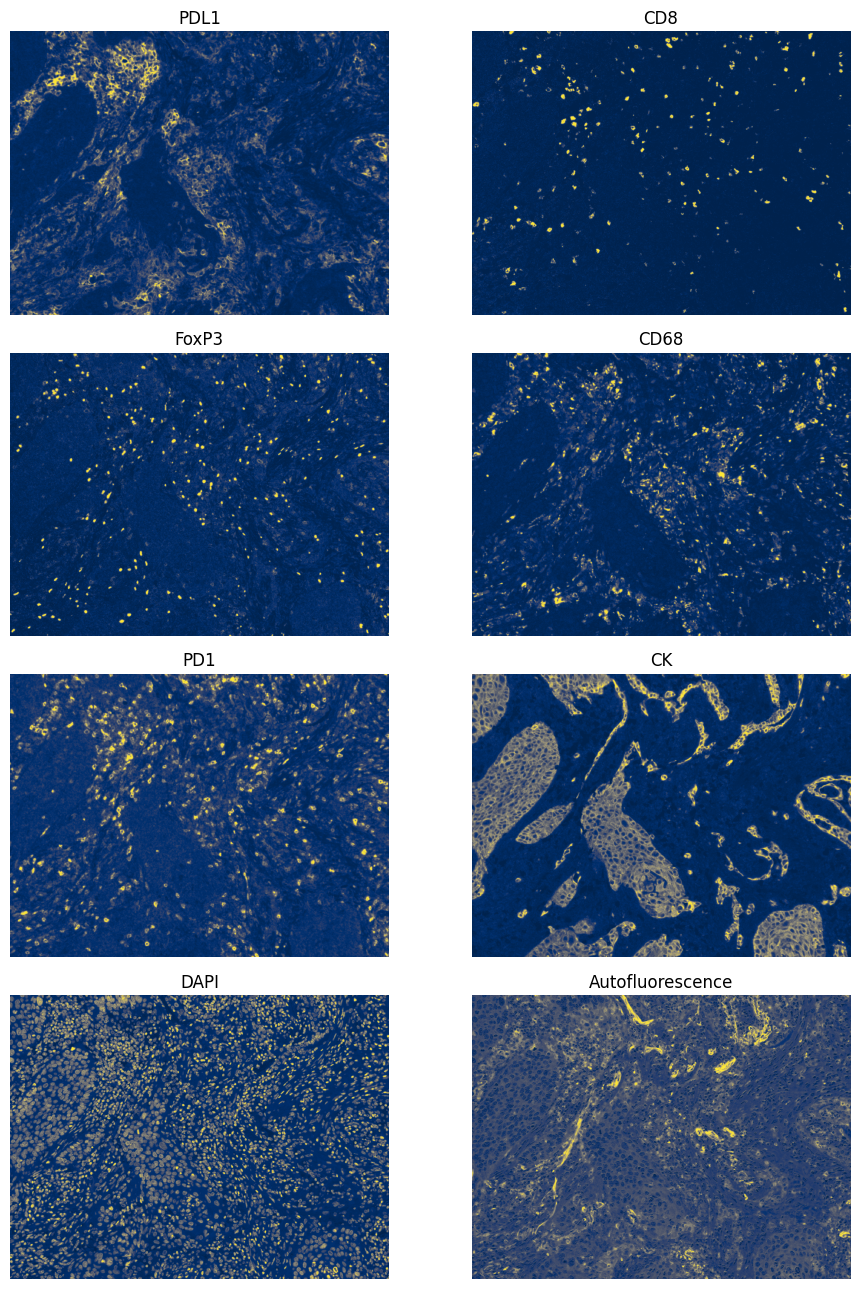

In [36]:
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

fig, axes = plt.subplots(4, 2, figsize=(10, 13))
_image_name = "image"
to_coordinate_system = "global"

se = hp.im.get_dataarray(sdata, element_name=_image_name)
channels = se.c.data

for _ax, _channel in zip(axes.flatten(), channels, strict=True):
    # normalization parameters for visualization (underlying image not changed)
    _channel_idx = np.where(channels == _channel)[0].item()
    vmax = da.percentile(se.data[_channel_idx].flatten(), q=99).compute()
    norm = Normalize(vmax=vmax, clip=False)

    render_images_kwargs = {"cmap": "cividis", "norm": norm}
    show_kwargs = {"title": _channel, "colorbar": False}
    _ax = hp.pl.plot_sdata(
        sdata,
        image_name=_image_name,
        channel=_channel,
        to_coordinate_system=to_coordinate_system,
        render_images_kwargs=render_images_kwargs,
        show_kwargs=show_kwargs,
        ax=_ax,
    )
    # frameless figure
    _ax.axis("off")

plt.tight_layout()
plt.show()

### Intensity distributions

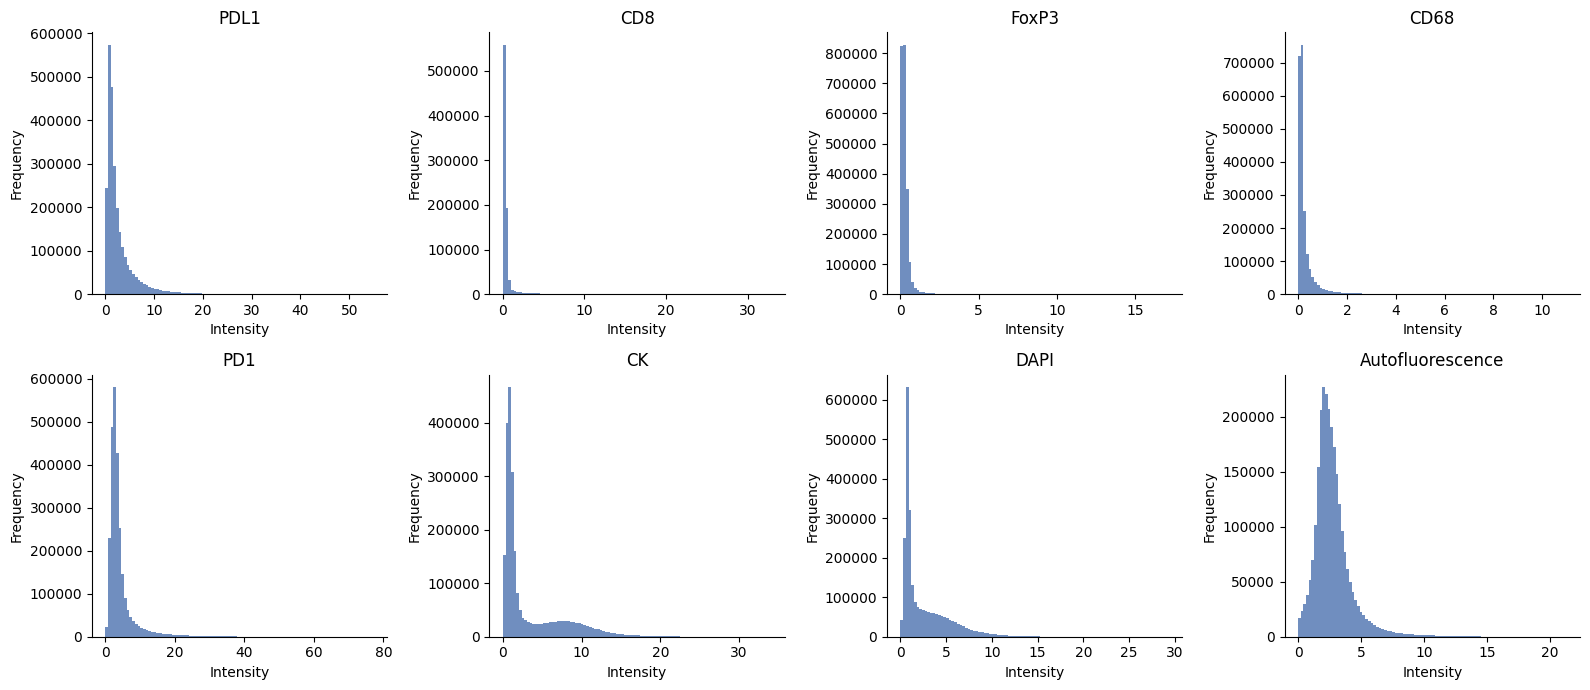

In [37]:
ax = hp.qc.image_histogram(
    sdata,
    image_name="image",
    channel=channels,
    ncols=4,
    bins=100,
)

## 3. Segment cells with InstanSeg

### Download the InstanSeg model

In [39]:
import os

import torch
from instanseg import InstanSeg

# Call the function to download and extract the models

instanseg_fluorescence = InstanSeg(
    "fluorescence_nuclei_and_cells", verbosity=1, device="cpu"
)

# or load the model from a path
path_model = os.path.join(
    os.environ.get("INSTANSEG_BIOIMAGEIO_PATH"),
    "fluorescence_nuclei_and_cells/0.1.1/instanseg.pt",
)

instanseg_fluorescence = torch.load(path_model, weights_only=False)
instanseg_fluorescence = InstanSeg(model_type=instanseg_fluorescence, device="cpu")

Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/utils/../bioimageio_models/, loading


/var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/ipykernel_95559/358850339.py:18: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_fluorescence = torch.load(path_model, weights_only=False)


We'll now segment the cells with `instanseg` implemented in Harpy. Check the [documentation](https://harpy.readthedocs.io/en/latest/generated/harpy.im.instanseg_callable.html).

In [41]:
import harpy as hp
from dask.distributed import Client, LocalCluster

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

sdata = hp.im.segment(
    sdata,
    image_name="image",
    output_labels_name=["labels_nuclei_harpy", "labels_cells_harpy"],
    output_shapes_name=["shapes_nuclei_harpy", "shapes_cells_harpy"],
    labels_name_align="labels_cells_harpy",
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="all_outputs",
    device=device,
    instanseg_model=path_model,  # load it in every worker, because torchscript model is not serializable
    pixel_size=0.5,
    overwrite=True,
)

client.close()

Using device: mps.
http://127.0.0.1:8787/status


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/image/segmentation/segmentation_models/_instanseg.py:78: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_model = torch.load(instanseg_model, weights_only=False)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1789: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/

2026-05-24 21:10:39,551 - tornado.application - ERROR - Uncaught exception GET /graph/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/graph/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app wi

,labels_name,total_instances,total_area_μm²,covered_area_μm²,covered_area_percentage
0,labels_cells_harpy,7195,653800.0,396108.75,60.585615


2026-05-24 21:00:33.911 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:162 - Calculating cell size for labels element 'labels_cells_harpy'.
2026-05-24 21:00:33.953 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:166 - Converting cell area from pixels to square microns using microns_per_pixel=0.5.


<Axes: xlabel='Instance Size (μm²)', ylabel='Number of instances'>

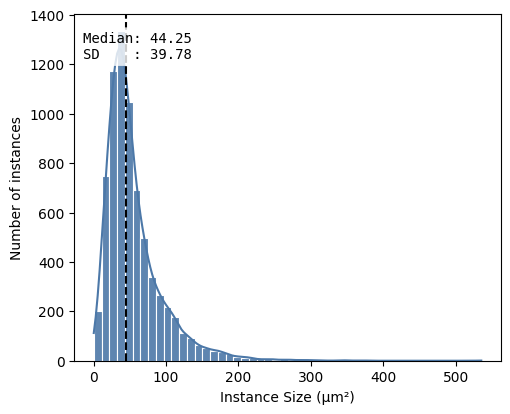

In [43]:
df = hp.qc.segmentation_coverage(
    sdata,
    labels_name="labels_cells_harpy",
    microns_per_pixel=0.5,
)
display(df)
hp.qc.segmentation_histogram(
    sdata,
    labels_name="labels_cells_harpy",
    microns_per_pixel=0.5,
    bins=50,
)

In [44]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

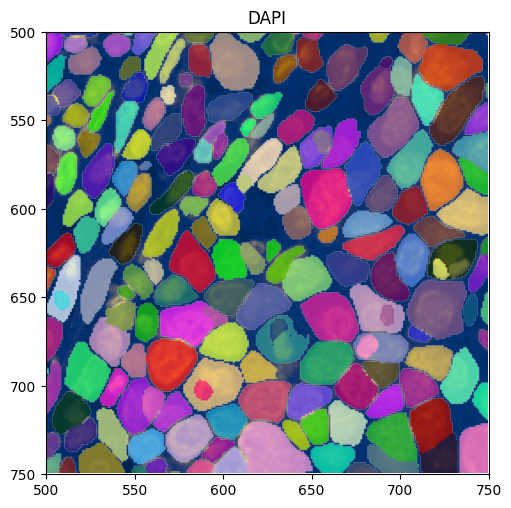

In [ ]:
norm = Normalize(vmin=0, vmax=10, clip=True)

channel = "DAPI"

render_images_kwargs = {
    "cmap": "cividis",
    "norm": norm,
}
render_labels_kwargs = {
    "fill_alpha": 0.8,
}

show_kwargs = {"title": channel, "colorbar": False, "dpi": 100, "figsize": (5, 5)}

ax = hp.pl.plot_sdata(
    sdata,
    image_name="image",
    render_images_kwargs=render_images_kwargs,
    render_labels_kwargs=render_labels_kwargs,
    labels_name="labels_cells_harpy",
    show_kwargs=show_kwargs,
    crd=[500, 750, 500, 750],
    channel=channel,
)

# -> segmentation looks a bit funky.

### Segment cells and nuclei separately

A better option is to segment cells and nuclei separately, and then align the cell and nuclei masks.

In [54]:
# Segment the cells
print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

print("Segmenting cells:")

sdata = hp.im.segment(
    sdata,
    image_name="image",
    output_labels_name=["labels_cells_harpy"],
    output_shapes_name=["shapes_cells_harpy"],
    labels_name_align=None,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="cells",
    device=device,
    instanseg_model=path_model,
    pixel_size=0.5,
    overwrite=True,
)

print("Segmenting nuclei:")

sdata = hp.im.segment(
    sdata,
    image_name="image",
    output_labels_name=["labels_nuclei_harpy"],
    output_shapes_name=["shapes_nuclei_harpy"],
    labels_layer_align=None,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="nuclei",
    device=device,
    instanseg_model=path_model,
    pixel_size=0.5,
    overwrite=True,
)

client.close()

Using device: mps.


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 62792 instead
  warnings.warn(


http://127.0.0.1:62792/status
Segmenting cells:


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/image/segmentation/segmentation_models/_instanseg.py:78: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_model = torch.load(instanseg_model, weights_only=False)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1789: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/

Segmenting nuclei:


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/image/segmentation/segmentation_models/_instanseg.py:78: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_model = torch.load(instanseg_model, weights_only=False)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
2026-05-25 10:11:43.575 | INFO     | harpy.image.segmentation._segmentation:_segment:681 - Linking labels across chunks.
2026-05-25 10:11:43.579 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_nuclei_harpy'
no parent found for <ome_zarr.reader.Label object at 0x13ceabfe0>: None
no parent found for <ome_zarr.reader.Label ob

2026-05-25 10:35:09,409 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:62792', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app

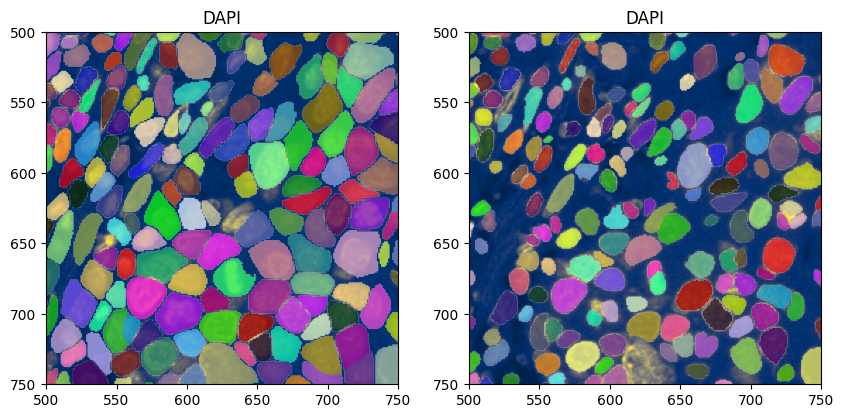

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(10, 20))

norm = Normalize(vmin=0, vmax=10, clip=True)

channel = "DAPI"

render_images_kwargs = {
    "cmap": "cividis",
    "norm": norm,
}
render_labels_kwargs = {
    "fill_alpha": 0.8,
}

show_kwargs = {
    "title": channel,
    "colorbar": False,
}

for _ax, _mask in zip(axes.flatten(), ["labels_cells_harpy", "labels_nuclei_harpy"]):
    hp.pl.plot_sdata(
        sdata,
        image_name="image",
        render_images_kwargs=render_images_kwargs,
        render_labels_kwargs=render_labels_kwargs,
        labels_name=_mask,
        show_kwargs=show_kwargs,
        crd=[500, 750, 500, 750],
        channel=channel,
        ax=_ax,
    )

In [63]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

### Align cell and nuclear masks

In [67]:
# better to combine.
sdata = hp.im.align_labels(
    sdata,
    labels_name_1="labels_nuclei_harpy",
    labels_name_2="labels_cells_harpy",
    output_labels_name="labels_nuclei_aligned_harpy",
    output_shapes_name="shapes_nuclei_aligned_harpy",
    chunks=None,
    overwrite=True,
)

2026-05-25 10:21:52.367 | INFO     | harpy.image.segmentation._map:_combine_dask_arrays:339 - Linking labels across chunks.
2026-05-25 10:21:52.397 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_nuclei_aligned_harpy'
no parent found for <ome_zarr.reader.Label object at 0x13dae76e0>: None
no parent found for <ome_zarr.reader.Label object at 0x14bc48ef0>: None
no parent found for <ome_zarr.reader.Label object at 0x35c55fd10>: None
no parent found for <ome_zarr.reader.Label object at 0x13dba94f0>: None
2026-05-25 10:21:52.662 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'labels_nuclei_aligned_harpy' already exists. Overwriting...
no parent found for <ome_zarr.reader.Label object at 0x35f899df0>: None
no parent found for <ome_zarr.reader.Label object at 0x14bc49850>: None
no parent found for <ome_zarr.reader.Label object at 0x35f5ca4b0>: None
no parent found for <ome_zarr.reader.Label object at 0x14bc121b0>: None
2026-05

In [68]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")  # -> interactively check if alignment went well.

2026-05-25 10:26:59.149 | INFO     | harpy.plot._sanity:sanity:269 - Selecting boundaries
2026-05-25 10:26:59.152 | INFO     | harpy.plot._sanity:sanity:306 - Plotting boundaries
2026-05-25 10:26:59.177 | INFO     | harpy.plot._sanity:sanity:314 - End plotting boundaries


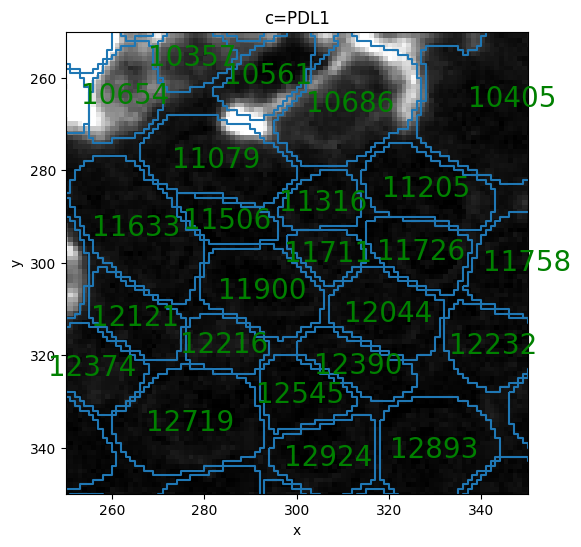

2026-05-25 10:26:59.248 | INFO     | harpy.plot._sanity:sanity:269 - Selecting boundaries
2026-05-25 10:26:59.250 | INFO     | harpy.plot._sanity:sanity:306 - Plotting boundaries
2026-05-25 10:26:59.271 | INFO     | harpy.plot._sanity:sanity:314 - End plotting boundaries


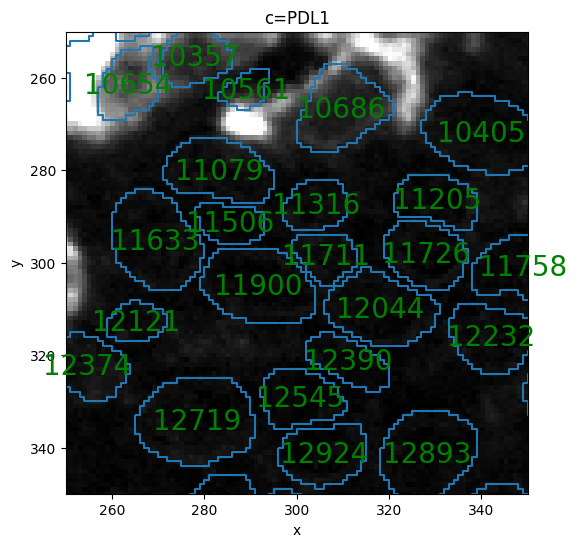

2026-05-25 10:26:59.341 | INFO     | harpy.plot._sanity:sanity:269 - Selecting boundaries
2026-05-25 10:26:59.344 | INFO     | harpy.plot._sanity:sanity:306 - Plotting boundaries
2026-05-25 10:26:59.367 | INFO     | harpy.plot._sanity:sanity:314 - End plotting boundaries


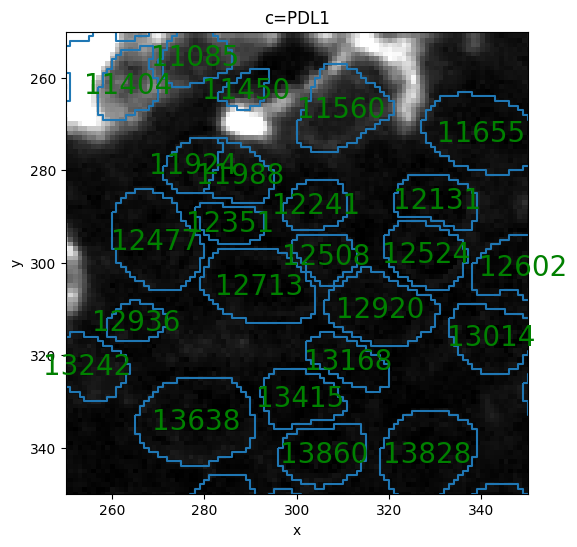

In [75]:
hp.pl.sanity(
    sdata,
    image_name="image",
    shapes_name="shapes_cells_harpy",
    points_name=None,
    crd=[250, 350, 250, 350],
    plot_cell_number=True,
    figsize=(6, 6),
)

hp.pl.sanity(
    sdata,
    image_name="image",
    shapes_name="shapes_nuclei_aligned_harpy",
    points_name=None,
    crd=[250, 350, 250, 350],
    plot_cell_number=True,
    figsize=(6, 6),
)

hp.pl.sanity(
    sdata,
    image_name="image",
    shapes_name="shapes_nuclei_harpy",
    points_name=None,
    crd=[250, 350, 250, 350],
    plot_cell_number=True,
    figsize=(6, 6),
)

## 4. Quantify protein intensities from InstanSeg masks

### Cell intensity table

In [79]:
sdata = hp.tb.allocate_intensity(
    sdata,
    image_name="image",
    labels_name="labels_cells_harpy",
    output_table_name="table_intensities_cells",
    channels=[
        "PDL1",
        "CD8",
        "FoxP3",
        "CD68",
        "PD1",
        "CK",
    ],  # do not include DAPI and Autofluorescence
    mode="mean",
    obs_stats=["count", "var", "kurtosis"],
    calculate_center_of_mass=True,
    to_coordinate_system="global",
    overwrite=True,
)

2026-05-25 10:31:27.248 | WARNING  | harpy.table._allocation_intensity:allocate_intensity:167 - No image element specified. Extracting intensities from the last image element 'image' of the provided SpatialData object.
2026-05-25 10:31:27.505 | WARNING  | harpy.utils._aggregate:_aggregate_stats:719 - Replacing NaN values in 'kurtosis' with 0 for affected instances.
2026-05-25 10:31:27.514 | WARNING  | harpy.utils._aggregate:_center_of_mass:884 - Count was computed for a different index. Recalculating.


In [82]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

In [83]:
sdata["table_intensities_cells"].to_df().head()

channels,PDL1,CD8,FoxP3,CD68,PD1,CK
cells,,,,,,
1881_labels_cells_harpy_2b0a41ab,0.914417,0.052260,0.195168,0.077198,2.624104,8.215117
1961_labels_cells_harpy_2b0a41ab,1.179779,0.050591,0.178932,0.073887,2.550712,7.094533
2027_labels_cells_harpy_2b0a41ab,0.768209,0.036718,0.146733,0.066700,1.872091,0.518552
2041_labels_cells_harpy_2b0a41ab,1.163384,0.106025,0.228085,0.097704,3.121188,9.876914
2075_labels_cells_harpy_2b0a41ab,1.322205,0.072041,0.201172,0.143287,2.240836,0.695029


In [84]:
sdata["table_intensities_cells"].obs.head()

,cell_ID,fov_labels,shapeSize,var_PDL1,var_CD8,var_FoxP3,var_CD68,var_PD1,var_CK,kurtosis_PDL1,kurtosis_CD8,kurtosis_FoxP3,kurtosis_CD68,kurtosis_PD1,kurtosis_CK
cells,,,,,,,,,,,,,,,
1881_labels_cells_harpy_2b0a41ab,1881,labels_cells_harpy,580.0,0.203115,0.011559,0.015329,0.002967,0.304981,13.646414,8.168401,6.822946,1.968510,-0.186784,0.309544,-1.144861
1961_labels_cells_harpy_2b0a41ab,1961,labels_cells_harpy,825.0,0.382006,0.011610,0.012233,0.003463,0.893363,10.169553,3.189152,8.116076,-0.016764,0.199105,1.005290,-0.538979
2027_labels_cells_harpy_2b0a41ab,2027,labels_cells_harpy,310.0,0.199238,0.007915,0.016493,0.002190,0.367338,0.073512,-0.321144,10.256311,1.290601,-0.953205,0.025045,-0.225175
2041_labels_cells_harpy_2b0a41ab,2041,labels_cells_harpy,424.0,0.184064,0.028609,0.017291,0.003281,0.757912,5.242445,1.290626,2.568351,-0.375567,0.291269,-0.122610,-0.452876
2075_labels_cells_harpy_2b0a41ab,2075,labels_cells_harpy,134.0,0.332244,0.021214,0.018993,0.007195,0.125776,0.073978,1.223719,2.212883,-0.707130,0.545457,-0.482599,0.100172


### Nuclear intensity table

In [109]:
sdata = hp.tb.allocate_intensity(
    sdata,
    image_name="image",
    labels_name="labels_nuclei_aligned_harpy",
    output_table_name="table_intensities_nuclei",
    channels=[
        "PDL1",
        "CD8",
        "FoxP3",
        "CD68",
        "PD1",
        "CK",
    ],  # do not include DAPI and Autofluorescence
    mode="mean",
    obs_stats=["count", "var", "kurtosis"],
    calculate_center_of_mass=True,
    to_coordinate_system="global",
    overwrite=True,
)

2026-05-25 17:11:43.901 | WARNING  | harpy.table._allocation_intensity:allocate_intensity:167 - No image element specified. Extracting intensities from the last image element 'image' of the provided SpatialData object.
2026-05-25 17:11:44.179 | WARNING  | harpy.utils._aggregate:_aggregate_stats:719 - Replacing NaN values in 'kurtosis' with 0 for affected instances.
2026-05-25 17:11:44.186 | WARNING  | harpy.utils._aggregate:_center_of_mass:884 - Count was computed for a different index. Recalculating.


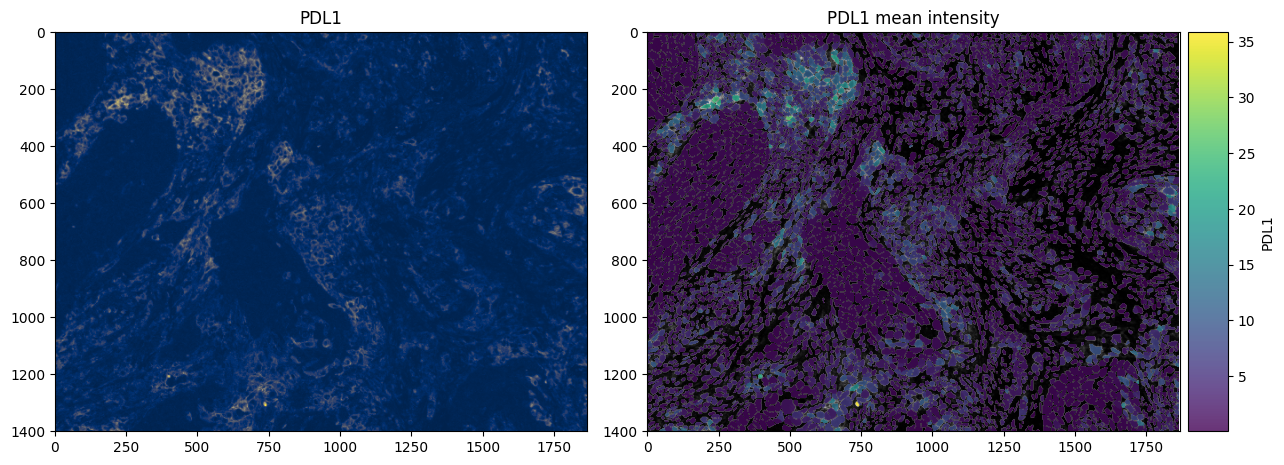

In [111]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = hp.pl.plot_sdata(
    sdata,
    image_name="image",
    channel="PDL1",
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "cividis", "colorbar": False},
    show_kwargs={"title": "PDL1", "colorbar": True},
    ax=axes[0],
)

ax = hp.pl.plot_sdata(
    sdata,
    image_name="image",
    channel="PDL1",
    table_name="table_intensities_cells",
    labels_name="labels_cells_harpy",
    color="PDL1",
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey", "colorbar": False},
    render_labels_kwargs={"fill_alpha": 0.8},
    show_kwargs={"title": "PDL1 mean intensity", "colorbar": True},
    ax=axes[1],
)

plt.tight_layout()

## 5. Segment marker-specific masks with Cellpose

In [122]:
hp.im.get_dataarray(sdata, element_name="image").c.data

array(['PDL1', 'CD8', 'FoxP3', 'CD68', 'PD1', 'CK', 'DAPI',
       'Autofluorescence'], dtype='<U16')

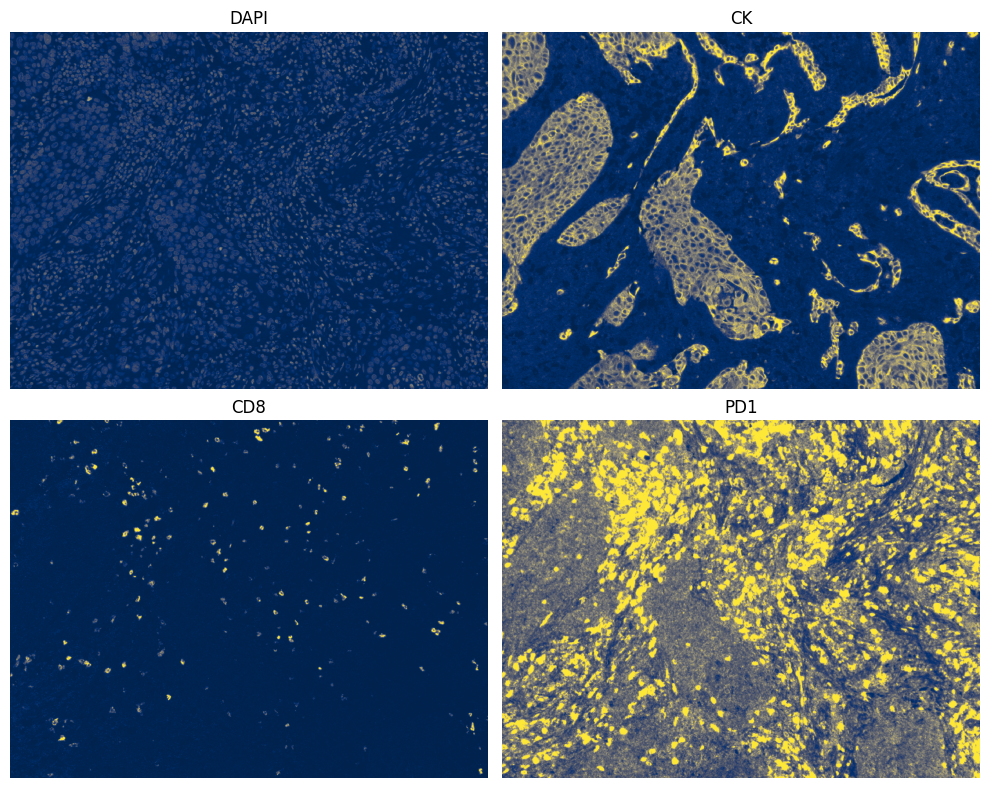

In [150]:
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
_image_name = "image"
to_coordinate_system = "global"

channels = np.array(["DAPI", "CK", "CD8", "PD1"])

for _ax, _channel in zip(axes.flatten(), channels, strict=True):
    # normalization parameters for visualization (underlying image not changed)
    _channel_idx = np.where(channels == _channel)[0].item()
    vmax = da.percentile(se.data[_channel_idx].flatten(), q=99.9).compute()
    norm = Normalize(vmax=vmax, clip=False)

    render_images_kwargs = {"cmap": "cividis", "norm": norm}
    show_kwargs = {"title": _channel, "colorbar": False}
    _ax = hp.pl.plot_sdata(
        sdata,
        image_name=_image_name,
        channel=_channel,
        to_coordinate_system=to_coordinate_system,
        render_images_kwargs=render_images_kwargs,
        show_kwargs=show_kwargs,
        ax=_ax,
    )
    # frameless figure
    _ax.axis("off")

plt.tight_layout()
plt.show()

In [151]:
se = hp.im.get_dataarray(sdata, element_name="image")
se.c.data  # -> channels

array(['PDL1', 'CD8', 'FoxP3', 'CD68', 'PD1', 'CK', 'DAPI',
       'Autofluorescence'], dtype='<U16')

In [155]:
cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

arr = se.sel(c="DAPI").data[None, ...]

sdata = hp.im.add_image(
    sdata,
    arr=arr.rechunk((1, 2048, 2048)),
    output_image_name="image_DAPI",
    c_coords=["DAPI"],
    overwrite=True,
)

# nuclei segmentation
print("Segmenting DAPI.")

sdata = hp.im.segment(
    sdata,
    image_name="image_DAPI",
    model=hp.im.cellpose_callable,
    device=device,
    pretrained_model="nuclei",
    output_labels_name="labels_cells_DAPI",
    output_shapes_name="shapes_cells_DAPI",
    diameter=15,
    depth=50,
    channels=[0, 0],
    overwrite=True,
)

# cell segmentation

for _channel in [
    "CK",
    "CD8",
    "PD1",
]:
    print(f"Segmenting {_channel}.")

    arr = se.sel(c=_channel).data[None, ...]

    sdata = hp.im.add_image(
        sdata,
        arr=arr.rechunk((1, 2048, 2048)),
        output_image_name=f"image_{_channel}",
        c_coords=_channel,
        overwrite=True,
    )

    sdata = hp.im.segment(
        sdata,
        image_name=f"image_{_channel}",
        model=hp.im.cellpose_callable,
        device=device,
        pretrained_model="cyto3",
        output_labels_name=f"labels_cells_{_channel}",
        output_shapes_name=f"shapes_cells_{_channel}",
        diameter=30,
        depth=50,
        channels=[0, 0],
        overwrite=True,
    )

client.close()

2026-05-25 18:21:35.829 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'image_DAPI'
2026-05-25 18:21:37.308 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'image_DAPI' already exists. Overwriting...


Segmenting DAPI.


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
2026-05-25 18:21:49.079 | INFO     | harpy.image.segmentation._segmentation:_segment:681 - Linking labels across chunks.
2026-05-25 18:21:49.084 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_cells_DAPI'
no parent found for <ome_zarr.reader.Label object at 0x35dc70fe0>: None
no parent found for <ome_zarr.reader.Label objec

Segmenting CK.


2026-05-25 18:21:50.915 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'image_CK' already exists. Overwriting...
2026-05-25 18:21:53.478 | INFO     | harpy.image.segmentation._segmentation:_segment:681 - Linking labels across chunks.
2026-05-25 18:21:53.483 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_cells_CK'
no parent found for <ome_zarr.reader.Label object at 0x633bbd3a0>: None
no parent found for <ome_zarr.reader.Label object at 0x3581ce720>: None
no parent found for <ome_zarr.reader.Label object at 0x622d40770>: None
no parent found for <ome_zarr.reader.Label object at 0x633bbd5b0>: None
no parent found for <ome_zarr.reader.Label object at 0x633ba1790>: None
no parent found for <ome_zarr.reader.Label object at 0x622dbffe0>: None
no parent found for <ome_zarr.reader.Label object at 0x37f5a5340>: None
no parent found for <ome_zarr.reader.Label object at 0x3581cf4d0>: None
no parent found for <ome_zarr.reader.Labe

Segmenting CD8.


2026-05-25 18:21:54.994 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'image_CD8' already exists. Overwriting...
2026-05-25 18:21:57.137 | INFO     | harpy.image.segmentation._segmentation:_segment:681 - Linking labels across chunks.
2026-05-25 18:21:57.142 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_cells_CD8'
no parent found for <ome_zarr.reader.Label object at 0x633b45ee0>: None
no parent found for <ome_zarr.reader.Label object at 0x633d7b530>: None
no parent found for <ome_zarr.reader.Label object at 0x633ba2210>: None
no parent found for <ome_zarr.reader.Label object at 0x633db5a60>: None
no parent found for <ome_zarr.reader.Label object at 0x633c7ae10>: None
no parent found for <ome_zarr.reader.Label object at 0x633bbfb00>: None
no parent found for <ome_zarr.reader.Label object at 0x633dcf8c0>: None
no parent found for <ome_zarr.reader.Label object at 0x633d2deb0>: None
no parent found for <ome_zarr.reader.La

Segmenting PD1.


2026-05-25 18:21:58.506 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'image_PD1' already exists. Overwriting...
2026-05-25 18:22:02.041 | INFO     | harpy.image.segmentation._segmentation:_segment:681 - Linking labels across chunks.
2026-05-25 18:22:02.045 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_cells_PD1'
no parent found for <ome_zarr.reader.Label object at 0x633e334d0>: None
no parent found for <ome_zarr.reader.Label object at 0x633e8f1a0>: None
no parent found for <ome_zarr.reader.Label object at 0x633bbfb60>: None
no parent found for <ome_zarr.reader.Label object at 0x633e8fcb0>: None
no parent found for <ome_zarr.reader.Label object at 0x634062690>: None
no parent found for <ome_zarr.reader.Label object at 0x633e8cd70>: None
no parent found for <ome_zarr.reader.Label object at 0x633e78500>: None
no parent found for <ome_zarr.reader.Label object at 0x633c7bf50>: None
no parent found for <ome_zarr.reader.La

In [152]:
hp.im.get_dataarray(sdata, element_name="image").c.data

array(['PDL1', 'CD8', 'FoxP3', 'CD68', 'PD1', 'CK', 'DAPI',
       'Autofluorescence'], dtype='<U16')

### Merge marker-specific masks

In [185]:
sdata = hp.im.merge_labels(
    sdata,
    priority_labels_name="labels_cells_CD8",
    candidate_labels_name="labels_cells_CK",
    output_labels_name="labels_cells_merged",
    output_shapes_name="shapes_cells_merged",
    threshold=0.3,
    overwrite=True,
)

sdata = hp.im.merge_labels(
    sdata,
    priority_labels_name="labels_cells_merged",
    candidate_labels_name="labels_cells_PD1",
    output_labels_name="labels_cells_merged",  # we overwrite
    output_shapes_name="shapes_cells_merged",
    threshold=0.2,
    overwrite=True,
)

2026-05-25 20:07:56.533 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_cells_merged'
no parent found for <ome_zarr.reader.Label object at 0x6335c1dc0>: None
no parent found for <ome_zarr.reader.Label object at 0x395ec7b00>: None
no parent found for <ome_zarr.reader.Label object at 0x63ad5d0d0>: None
no parent found for <ome_zarr.reader.Label object at 0x6252534d0>: None
no parent found for <ome_zarr.reader.Label object at 0x638d980b0>: None
no parent found for <ome_zarr.reader.Label object at 0x64102b4d0>: None
no parent found for <ome_zarr.reader.Label object at 0x63b587230>: None
no parent found for <ome_zarr.reader.Label object at 0x63a3ccd40>: None
no parent found for <ome_zarr.reader.Label object at 0x63a0e2ea0>: None
no parent found for <ome_zarr.reader.Label object at 0x3994330b0>: None
2026-05-25 20:07:56.878 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'labels_cells_merged' already exists. Overwriting...
no 

In [205]:
Interactive(sdata, widgets="viewer")

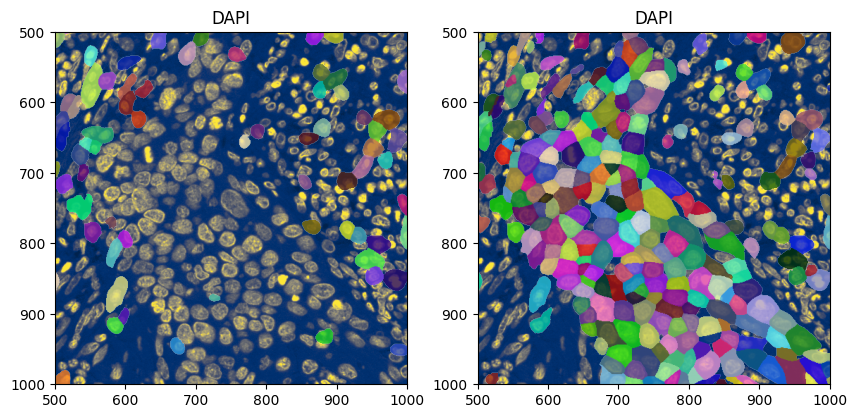

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(10, 20))

norm = Normalize(vmin=0, vmax=10, clip=True)

channel = "DAPI"

render_images_kwargs = {
    "cmap": "cividis",
    "norm": norm,
}
render_labels_kwargs = {
    "fill_alpha": 0.8,
}

show_kwargs = {
    "title": channel,
    "colorbar": False,
}

for _ax, _mask in zip(axes.flatten(), ["labels_cells_PD1", "labels_cells_merged"]):
    hp.pl.plot_sdata(
        sdata,
        image_name="image",
        render_images_kwargs=render_images_kwargs,
        render_labels_kwargs=render_labels_kwargs,
        labels_name=_mask,
        show_kwargs=show_kwargs,
        crd=[500, 1000, 500, 1000],
        channel=channel,
        ax=_ax,
    )

### Expand and merge nuclear masks

Let's expand the segmentation masks of the nuclei (`'labels_cells_DAPI'`).

See the [documentation](https://harpy.readthedocs.io/en/latest/generated/harpy.im.expand_labels.html).

In [187]:
sdata = hp.im.expand_labels(
    sdata,
    labels_name="labels_cells_DAPI",
    distance=10,
    output_labels_name="labels_cells_DAPI_expanded",
    output_shapes_name="shapes_cells_DAPI_expanded",
    overwrite=True,
)

2026-05-25 20:08:10.453 | INFO     | harpy.image.segmentation._map:_combine_dask_arrays:339 - Linking labels across chunks.
2026-05-25 20:08:10.465 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_cells_DAPI_expanded'
no parent found for <ome_zarr.reader.Label object at 0x6244e04a0>: None
no parent found for <ome_zarr.reader.Label object at 0x63b5f6ff0>: None
no parent found for <ome_zarr.reader.Label object at 0x63a9bd730>: None
no parent found for <ome_zarr.reader.Label object at 0x63b60b620>: None
no parent found for <ome_zarr.reader.Label object at 0x63b66bcb0>: None
no parent found for <ome_zarr.reader.Label object at 0x63b6c6930>: None
no parent found for <ome_zarr.reader.Label object at 0x6392bb6e0>: None
no parent found for <ome_zarr.reader.Label object at 0x63b602210>: None
no parent found for <ome_zarr.reader.Label object at 0x6346aa2d0>: None
no parent found for <ome_zarr.reader.Label object at 0x63b6008c0>: None
2026-05-25 20:08:10.837 |

<Axes: title={'center': 'DAPI'}>

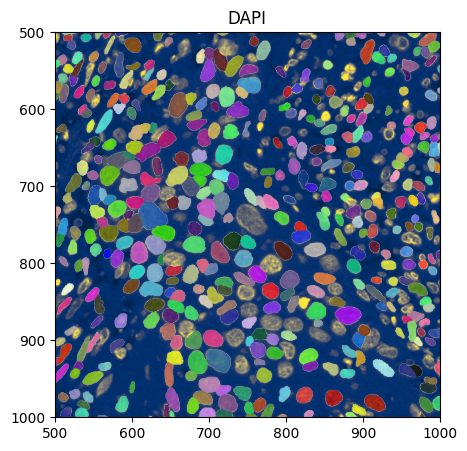

In [188]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

norm = Normalize(vmin=0, vmax=10, clip=True)

channel = "DAPI"

render_images_kwargs = {
    "cmap": "cividis",
    "norm": norm,
}
render_labels_kwargs = {
    "fill_alpha": 0.8,
}

show_kwargs = {
    "title": channel,
    "colorbar": False,
}

hp.pl.plot_sdata(
    sdata,
    image_name="image",
    render_images_kwargs=render_images_kwargs,
    render_labels_kwargs=render_labels_kwargs,
    labels_name="labels_cells_DAPI",
    show_kwargs=show_kwargs,
    crd=[500, 1000, 500, 1000],
    channel=channel,
    ax=ax,
)

In [189]:
# now merge them
sdata = hp.im.merge_labels_nuclei(
    sdata,
    labels_name="labels_cells_merged",
    labels_name_nuclei="labels_cells_DAPI",  # nuclei
    labels_name_nuclei_expanded="labels_cells_DAPI_expanded",  # nuclei expanded
    output_labels_name="labels_cells_merged",
    output_shapes_name="shapes_cells_merged",
    threshold=0.1,
    overwrite=True,
)

2026-05-25 20:08:36.845 | INFO     | harpy.image.segmentation._map:_combine_dask_arrays:339 - Linking labels across chunks.
2026-05-25 20:08:36.855 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_cells_merged'
no parent found for <ome_zarr.reader.Label object at 0x6410e1d30>: None
no parent found for <ome_zarr.reader.Label object at 0x63b2486b0>: None
no parent found for <ome_zarr.reader.Label object at 0x396418fe0>: None
no parent found for <ome_zarr.reader.Label object at 0x63b249880>: None
no parent found for <ome_zarr.reader.Label object at 0x3993362a0>: None
no parent found for <ome_zarr.reader.Label object at 0x63b24ac00>: None
no parent found for <ome_zarr.reader.Label object at 0x14b8eea80>: None
no parent found for <ome_zarr.reader.Label object at 0x63b1e4bc0>: None
no parent found for <ome_zarr.reader.Label object at 0x638dc0950>: None
no parent found for <ome_zarr.reader.Label object at 0x641234bc0>: None
2026-05-25 20:08:37.177 | WARNIN

In [190]:
Interactive(sdata, widgets="viewer")

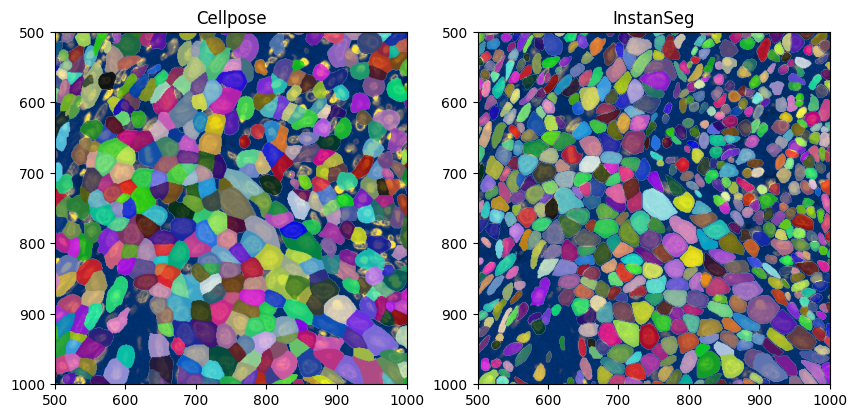

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 20))

norm = Normalize(vmin=0, vmax=10, clip=True)

channel = "DAPI"

render_images_kwargs = {
    "cmap": "cividis",
    "norm": norm,
}
render_labels_kwargs = {
    "fill_alpha": 0.8,
}

for _ax, _mask in zip(axes.flatten(), ["labels_cells_merged", "labels_cells_harpy"]):
    show_kwargs = {
        "title": "Cellpose" if _mask == "labels_cells_merged" else "InstanSeg",
        "colorbar": False,
    }

    hp.pl.plot_sdata(
        sdata,
        image_name="image",
        render_images_kwargs=render_images_kwargs,
        render_labels_kwargs=render_labels_kwargs,
        labels_name=_mask,
        show_kwargs=show_kwargs,
        crd=[500, 1000, 500, 1000],
        channel=channel,
        ax=_ax,
    )

## 6. Create the final table

Let's continue with the segmentation mask obtained through hierarchical clustering of the segmentation masks obtained through Cellpose.

Before aggregating protein intensities per cell, we first normalize the image channels using robust lower and upper percentiles:

```python
pmin = 0.1
pmax = 99.9
```

This percentile-based normalization brings the channels onto a comparable image-intensity scale while reducing the influence of a small number of extreme pixels. This is useful for spatial proteomics because different markers can have very different staining intensities, exposure ranges, background levels, and antibody-dependent dynamic ranges. Normalizing each channel before aggregation makes the resulting per-cell mean intensities less dominated by technical scale differences between channels.

After this image-level normalization, we aggregate the normalized signal over the final cell segmentation mask (`labels_cells_merged`). This gives one table with cells as rows and protein channels as columns, where each value summarizes the normalized marker intensity inside a cell.

Finally, we run `hp.tb.preprocess_proteomics(..., scale=True, ...)` on the aggregated table. Here we disable size normalization, library normalization, and log transformation because the table contains mean intensities from already normalized images rather than raw molecule counts. The scaling step z-scores each protein channel across cells, so each marker is centered and put on unit variance. This is a sensible preprocessing step before downstream analyses such as clustering, visualization, or marker comparison, because it prevents high-dynamic-range channels from dominating the analysis while preserving relative differences between cells for each marker. The `max_value_scale=5` cap limits the influence of extreme outlier cells after z-scoring.

### Aggregate normalized marker intensities

In [ ]:
channels = hp.im.get_dataarray(sdata, element_name="image").c.data
channels

array(['PDL1', 'CD8', 'FoxP3', 'CD68', 'PD1', 'CK', 'DAPI',
       'Autofluorescence'], dtype='<U16')

In [ ]:
from spatialdata import read_zarr

sdata = read_zarr(sdata.path)

no parent found for <ome_zarr.reader.Label object at 0x65e5759d0>: None
no parent found for <ome_zarr.reader.Label object at 0x65e567d70>: None
no parent found for <ome_zarr.reader.Label object at 0x6556a4ef0>: None
no parent found for <ome_zarr.reader.Label object at 0x65e564ad0>: None
no parent found for <ome_zarr.reader.Label object at 0x65e5fc110>: None
no parent found for <ome_zarr.reader.Label object at 0x65e564ad0>: None
no parent found for <ome_zarr.reader.Label object at 0x65e644cb0>: None
no parent found for <ome_zarr.reader.Label object at 0x65e5fc710>: None
no parent found for <ome_zarr.reader.Label object at 0x65e647110>: None


In [ ]:
pmin = 0.1
pmax = 99.9

sdata = hp.im.normalize(
    sdata,
    image_name="image",
    output_image_name="image_normalized",
    p_min=len(channels) * [pmin],
    p_max=len(channels) * [pmax],
    overwrite=True,
)

2026-05-25 20:46:25.452 | INFO     | harpy.image._map:_precondition:359 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'/'func' ({np.str_('PDL1'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD8'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('FoxP3'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD68'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('PD1'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CK'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('DAPI'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('Autofluorescence'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}}/{np.str_('PDL1'): <function _normalize at 0x6533a6660>, np.str_('CD8'): <function _normalize at 0x6533

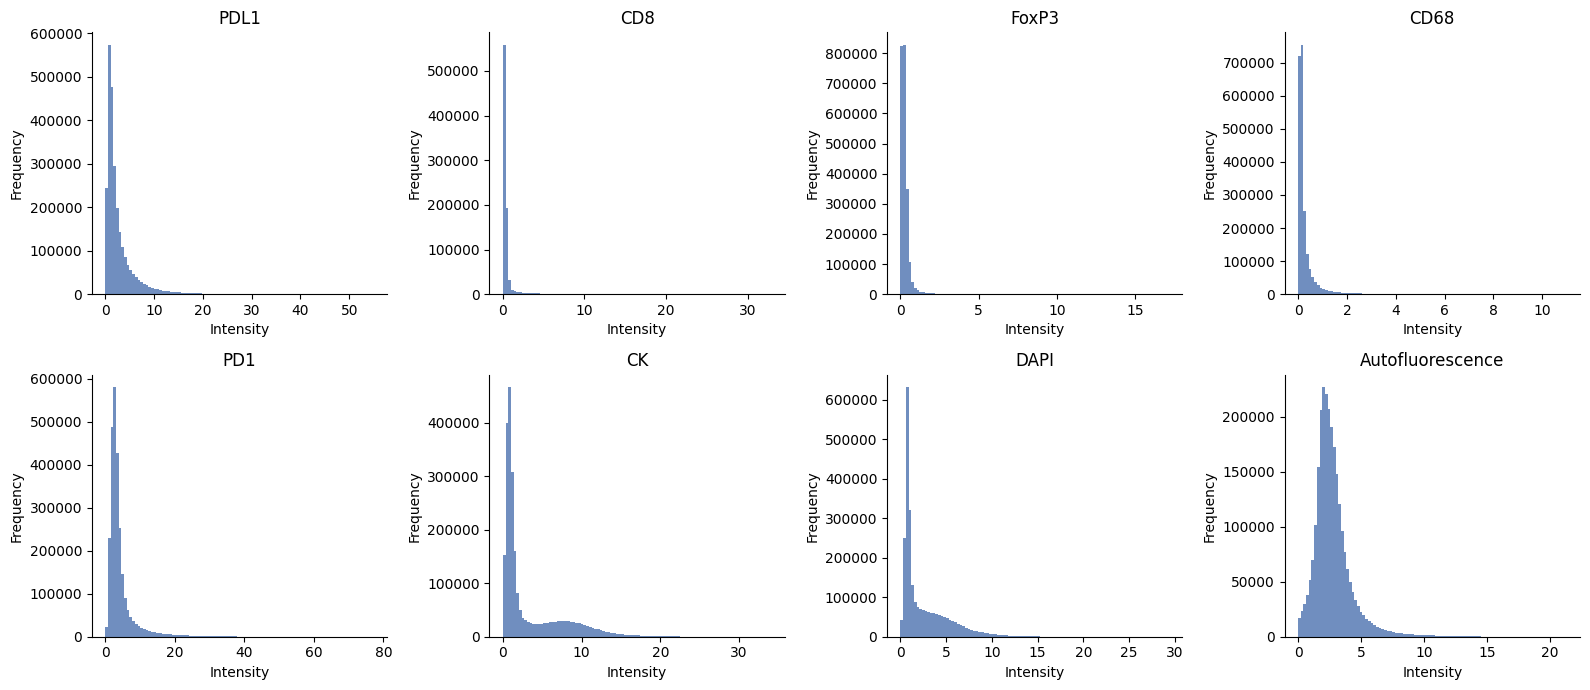

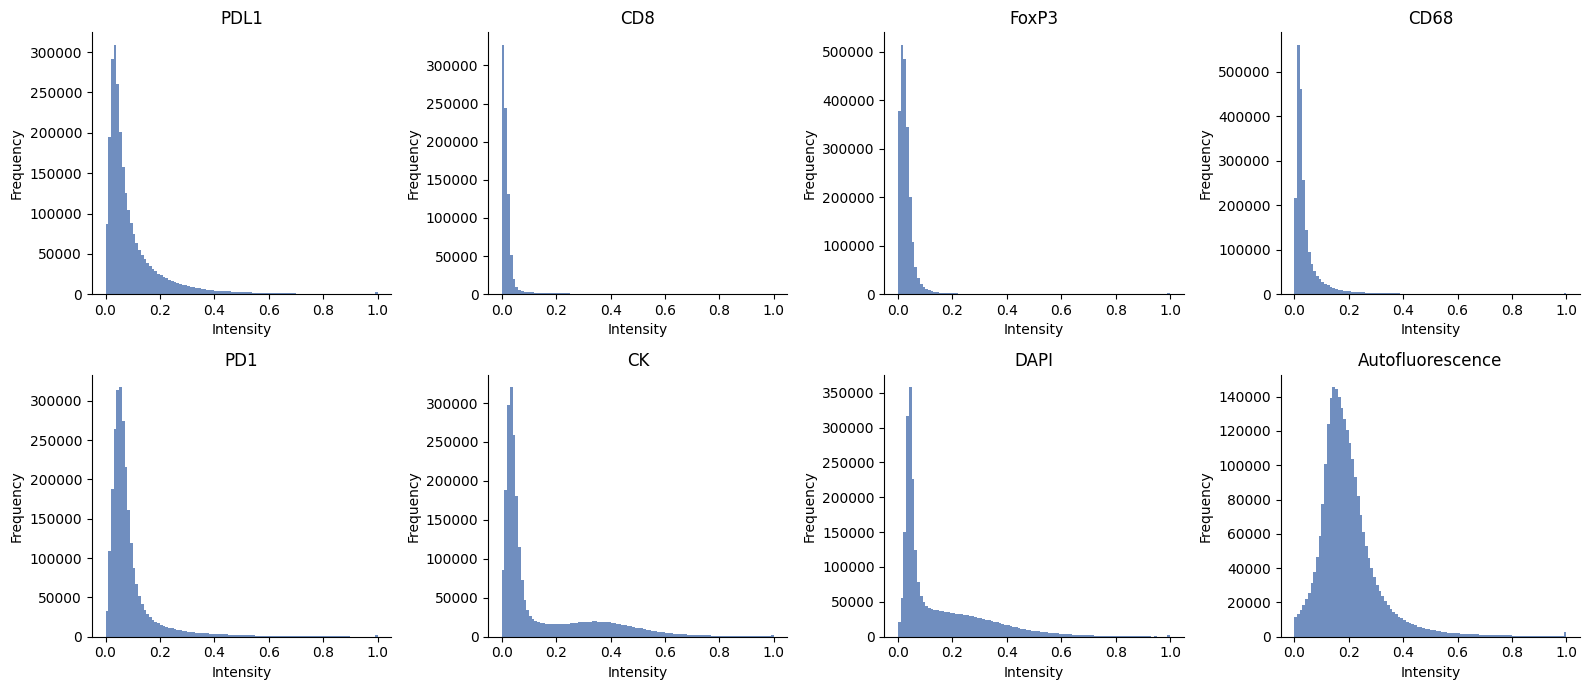

In [220]:
ax = hp.qc.image_histogram(
    sdata,
    image_name="image",
    channel=channels,
    ncols=4,
    bins=100,
)

ax = hp.qc.image_histogram(
    sdata,
    image_name="image_normalized",
    channel=channels,
    ncols=4,
    bins=100,
)

In [221]:
sdata = hp.tb.allocate_intensity(
    sdata,
    image_name="image_normalized",
    channels=[
        "PDL1",
        "CD8",
        "FoxP3",
        "CD68",
        "PD1",
        "CK",
    ],
    labels_name="labels_cells_merged",
    chunks=2048,
    output_table_name="table_intensities_cells_merged",
    mode="mean",
    obs_stats=["count", "var", "kurtosis"],
    calculate_center_of_mass=True,
    to_coordinate_system="global",
    overwrite=True,
)

2026-05-25 20:48:32.672 | WARNING  | harpy.utils._aggregate:_aggregate_stats:719 - Replacing NaN values in 'kurtosis' with 0 for affected instances.
2026-05-25 20:48:32.688 | WARNING  | harpy.utils._aggregate:_center_of_mass:884 - Count was computed for a different index. Recalculating.
2026-05-25 20:48:33.951 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_intensities_cells_merged' already exists. Overwriting...


### Scale protein features

Now z-scoring of the resulting intensities.

In [222]:
sdata = hp.tb.preprocess_proteomics(
    sdata,
    labels_name="labels_cells_merged",
    table_name="table_intensities_cells_merged",
    output_table_name="table_intensities_cells_merged_preprocessed",
    calculate_cell_size=False,
    size_norm=False,
    library_norm=False,
    log1p=False,
    scale=True,
    max_value_scale=5,
    q=None,
    calculate_pca=False,
    raw_counts_key="mean_counts",
    overwrite=True,
)


2026-05-25 20:49:48.731 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[mean_counts]'.


In [226]:
sdata["table_intensities_cells_merged"].to_df().head()

channels,PDL1,CD8,FoxP3,CD68,PD1,CK
cells,,,,,,
6_labels_cells_merged_720e93ed,0.043372,0.004862,0.119097,0.039529,0.083669,0.051772
8_labels_cells_merged_720e93ed,0.045692,0.025655,0.053283,0.014709,0.063963,0.082092
11_labels_cells_merged_720e93ed,0.269963,0.000152,0.066204,0.199128,0.260286,0.054110
13_labels_cells_merged_720e93ed,0.078709,0.007982,0.052014,0.034508,0.110935,0.048908
14_labels_cells_merged_720e93ed,0.040290,0.003613,0.062163,0.023206,0.058908,0.038447


In [ ]:
display(sdata["table_intensities_cells_merged_preprocessed"].to_df().mean())  # ~0
display(sdata["table_intensities_cells_merged_preprocessed"].to_df().std())  # ~1

channels
PDL1    -3.644374e-03
CD8     -2.498827e-02
FoxP3   -2.169042e-02
CD68    -1.115310e-02
PD1     -1.532328e-03
CK       6.057692e-07
dtype: float32

channels
PDL1     0.979261
CD8      0.821144
FoxP3    0.829296
CD68     0.924826
PD1      0.991274
CK       1.000000
dtype: float32

### Exercise: compare image signal and per-cell variance

Visualize the data by comparing the raw CD8 image channel with the per-cell CD8 variance (`var_CD8`).


<details>
<summary>Click to reveal the solution</summary>

```python

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = hp.pl.plot_sdata(
    sdata,
    image_name="image",
    channel="CD8",
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "cividis", "colorbar": False},
    show_kwargs={"title": "CD8", "colorbar": True},
    ax=axes[0],
)

ax = hp.pl.plot_sdata(
    sdata,
    image_name="image",
    channel="CD8",
    table_name="table_intensities_cells",
    labels_name="labels_cells_harpy",
    color="var_CD8",
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey", "colorbar": False},
    render_labels_kwargs={"fill_alpha": 0.8},
    show_kwargs={"title": "CD8 variance", "colorbar": True},
    ax=axes[1],
)

plt.tight_layout()
```

</details>

## 7. Cluster cells by protein phenotype

2026-05-25 20:55:25.736 | WARNING  | harpy.table._clustering:cluster:280 - 'neighbors' already in 'adata.uns', recalculating neighbors. Consider passing 'calculate_neigbors=False'.
2026-05-25 20:55:30.578 | WARNING  | harpy.table._clustering:cluster:293 - The column 'leiden' already exists in the Anndata object. Proceeding to overwrite it.
2026-05-25 20:55:33.589 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_intensities_cells_merged_preprocessed' already exists. Overwriting...


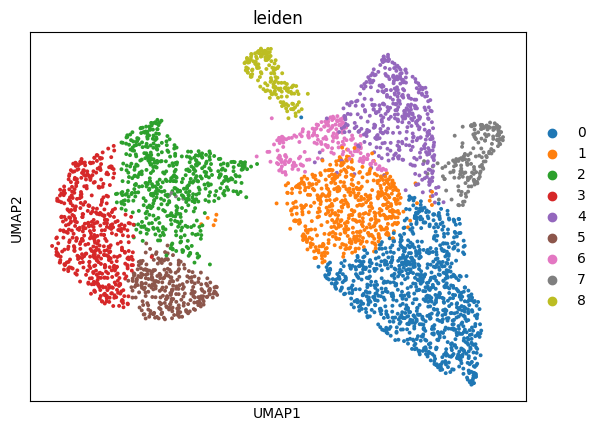

In [ ]:
import scanpy as sc

# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_name="labels_cells_merged",
    table_name="table_intensities_cells_merged_preprocessed",
    output_table_name="table_intensities_cells_merged_preprocessed",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17,  # The number of principal components to use when calculating neighbors.
    n_neighbors=35,  # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(
    sdata.tables["table_intensities_cells_merged_preprocessed"],
    color=["leiden"],
    show=True,
)

<Axes: title={'center': 'Leiden clusters'}>

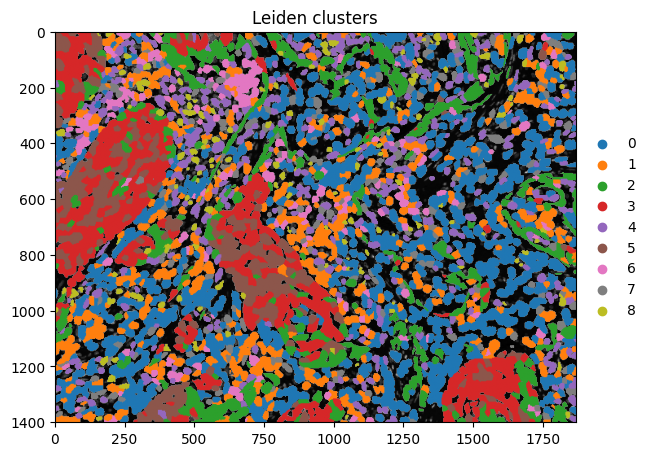

In [ ]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    image_name="image",
    channel="DAPI",
    table_name="table_intensities_cells_merged_preprocessed",
    labels_name="labels_cells_merged",
    color="leiden",
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Leiden clusters", "colorbar": False},
)

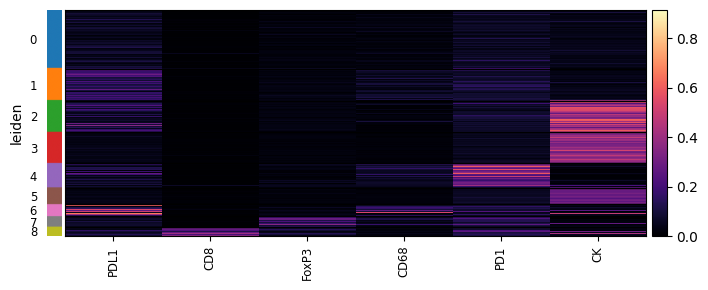

In [ ]:
sc.pl.heatmap(
    sdata["table_intensities_cells_merged_preprocessed"],
    var_names=sdata["table_intensities_cells_merged_preprocessed"].var_names,
    groupby="leiden",
    swap_axes=False,
    norm=None,
    cmap="magma",
    figsize=(8, 3),
    show_gene_labels=True,
)

2026-05-25 21:03:10.062 | INFO     | harpy.table._cluster_intensity:cluster_intensity:80 - Weighted (by instance size) average intensity per cluster (cluster key: 'leiden') will be stored in 'sdata[table_intensities_cells_merged_preprocessed].uns[leiden_weighted_intensity]'.
2026-05-25 21:03:10.073 | WARNING  | harpy.table._cluster_intensity:cluster_intensity:94 - Key 'leiden_weighted_intensity' found in sdata[table_intensities_cells_merged_preprocessed].uns. Object at that location will be removed and recalculated.
2026-05-25 21:03:12.165 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_intensities_cells_merged_preprocessed' already exists. Overwriting...
2026-05-25 21:03:14.159 | INFO     | harpy.table._manager:_cast_stringdtype_uns_sdata:122 - Casting key leiden_colors to '<U7'.


,leiden,PDL1,CD8,FoxP3,CD68,PD1,CK
0,0,0.061044,0.004622,0.020534,0.025014,0.060727,0.041687
1,1,0.158281,0.006210,0.029708,0.063503,0.086464,0.050330
2,2,0.117760,0.005277,0.031396,0.020475,0.083612,0.442079
3,3,0.036844,0.006122,0.020740,0.015216,0.054616,0.373631
4,4,0.124993,0.004572,0.031867,0.083012,0.315869,0.031233
5,5,0.035571,0.007794,0.020643,0.018566,0.062076,0.266717
6,6,0.289110,0.007253,0.034889,0.183049,0.096481,0.063110
7,7,0.115428,0.004224,0.182729,0.078898,0.155637,0.037806
8,8,0.110173,0.237613,0.060093,0.037897,0.134392,0.073887


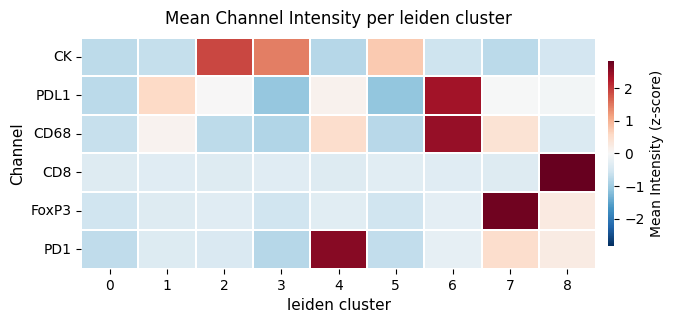

In [ ]:
# calculate the mean itensity per leiden cluster
cluster_key = "leiden"

sdata = hp.tb.cluster_intensity(
    sdata,
    table_name="table_intensities_cells_merged_preprocessed",
    labels_name="labels_cells_merged",
    output_table_name="table_intensities_cells_merged_preprocessed",
    cluster_key="leiden",
    layer_mean_intensities="mean_counts",
    cluster_key_uns=f"{cluster_key}_weighted_intensity",
    overwrite=True,
)

display(
    sdata["table_intensities_cells_merged_preprocessed"].uns[
        f"{cluster_key}_weighted_intensity"
    ]
)

ax = hp.pl.cluster_intensity_heatmap(
    sdata,
    table_name="table_intensities_cells_merged_preprocessed",
    cluster_key="leiden",
    z_score=True,
    figsize=(8, 3),
)

## 8. Spatial neighborhood analysis

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/1000 [00:00<?, ?/s]

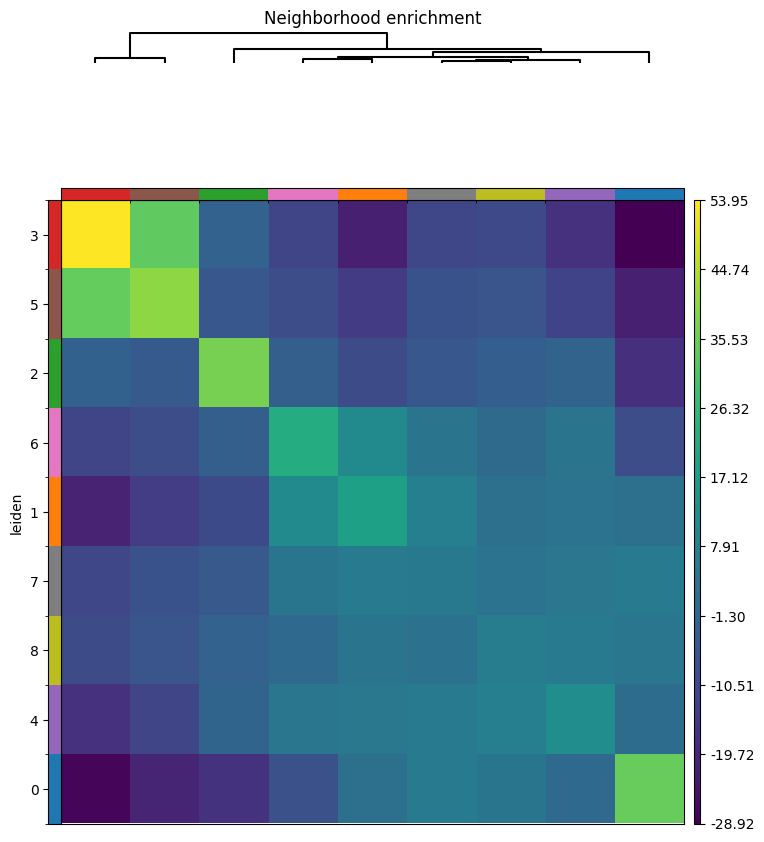

In [237]:
import numpy as np
import squidpy as sq

adata = sdata["table_intensities_cells_merged_preprocessed"]

cluster_key = "leiden"

sq.gr.spatial_neighbors(
    adata,
    spatial_key="spatial",
    copy=False,
)
sq.gr.nhood_enrichment(
    adata,
    cluster_key=cluster_key,
    seed=0,
    copy=False,
)

adata.uns[f"{cluster_key}_nhood_enrichment"]["zscore"] = np.nan_to_num(
    adata.uns[f"{cluster_key}_nhood_enrichment"]["zscore"]
)
sq.pl.nhood_enrichment(
    adata, cluster_key=cluster_key, method="ward", mode="zscore", figsize=(8, 8)
)

In [238]:
Interactive(sdata, widgets="viewer")

2026-05-25 21:05:59.168 | INFO     | napari_harpy.viewer.labels_styling:_resolve_categorical_palette:312 - Using stored `leiden_colors` palette from `table.uns` for viewer coloring.
